# Daniel's Guide to Quantifying Uncertainty in Turbulence Statistics

Uncertainty in statistics comes from three main sources:
1. **Measurement uncertainty:** errors introduced during data acquisition, e.g. from instrument noise
2. **Sampling/statistical uncertainty:** variability that arises when trying to estimate ensemble averages from a finite dataset. Greater in the tails of distributions or at scales with fewer contributing points (see Kiyani et al.) 
3. **Fitting uncertainty:** uncertainty in the parameters, e.g., power-law exponents, Taylor scale, obtained from fitting a model (like a straight-line in log-log space)

## Next steps
- Tidy below
    - See [ChatGPT convo](https://chatgpt.com/share/67fcd8ab-c87c-8012-8888-f1c7be3bc7cc)
    - Work with 48s Voyager data for de-biasing
    - Add equations from Overleaf

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add .. to the path
import sys

sys.path.append("..")
import src.sf_funcs as sf_funcs

## Measurement uncertainty

We often have uncertainty in our data due to **random/statistical** error. (There is separate component of data error called **systematic** error, which is a consistent offset to the true value and therefore can be easily corrected. It will not be discussed any further here.) We can represent this error as a random variable $\mathbf{\epsilon}$ that is added to the `true' value of our data $\mathbf{X}$, in order to get our observed values $\hat{\mathbf{X}}$:

$$\hat{\mathbf{X}}=\mathbf{X}+\mathbf{\epsilon}$$
Note the lack of dependence of error on the data index $i$: the measurement error is typically assumed to be independent and identically distributed (i.i.d.) across all observations $i$, and independent of the true signal. Additionally, it is modeled as normally distributed with zero mean and variance $\mathbf{\sigma}_{\mathbf{\epsilon}}^2$:

$$\mathbf{\epsilon}\sim N(0,\mathbf{\sigma}_{\mathbf{\epsilon}}^2)$$

We can get $\mathbf{\sigma}^2_\mathbf{\epsilon}$ by noting that typically data error bars in literature are expressed as $\mathbf{X}\pm\mathbf{\sigma}_\mathbf{\epsilon}$. (In some cases they may represent 95\% confidence intervals, in which case what is really expressed is $\mathbf{X}\pm1.96\mathbf{\sigma}_\mathbf{\epsilon}$.)

**This error does not affect the mean of our data**:

$$E[\hat{\mathbf{X}}]=E[\mathbf{X}+\mathbf{\epsilon}]=E[\mathbf{X}]+E[\mathbf{\epsilon}]=E[\mathbf{X}]$$

This follows from $E[A+B]=E[A]+E[B]$

**But it does inflate the variance**:

$$\text{Var}[\hat{\mathbf{X}}]=\text{Var}[\mathbf{X}+\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\text{Var}[\mathbf{\epsilon}]+\text{Cov}[X,\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\text{Var}[\mathbf{\epsilon}]=\text{Var}[\mathbf{X}]+\mathbf{\sigma}_{\mathbf{\epsilon}}^2$$

This follows from $\text{Var}(A+B)=\text{Var}(A)+\text{Var}(B)+\text{Cov}(A,B)$

**Seeing as the second-order structure function $\text{SF}$ is a measure of variance, it is also inflated by measurement error.** And since it is a function of two random variables $\mathbf{X}, X_j$, with the same error distribution, we get two times the error variance as our upwards bias:

$$E[\hat{\text{SF}}(\tau)]=\text{SF}(\tau)+2\mathbf{\sigma}_{\mathbf{\epsilon}}^2$$

The full derivation of this is given in \citet[Appendix A.3]{cucchetti2019} and \citet[Appendix B]{zuhone2016}. (In those papers, they represent $\mathbf{\sigma}_{\mathbf{\epsilon}}^2$ as $\mathbf{\sigma}^2_{stat}$, to distinguish it from the systematic error variance $\mathbf{\sigma}^2_{sys}$.) They then show the downwards correction of this bias in their Figures 3 and 5, respectively.

The former paper also derives the error that propagates into the four-term \textit{variance} of the structure function, which we need for calculating confidence intervals:

$$\text{Var}[\hat{\text{SF}}(\tau)]=\text{Var}[\text{SF}(\tau)]+4\text{Var}[\text{D}(\tau)]\mathbf{\sigma}_{\mathbf{\epsilon}}^2+\frac{4}{N(\tau)}\text{SF}(\tau)\mathbf{\sigma}_{\mathbf{\epsilon}}^2+\frac{4(N_{nei}(\tau)+1)}{N(\tau)}\mathbf{\sigma}_{\mathbf{\epsilon}}^4$$

where $D(\tau)$ is the increment function (first-order SF), $N(\tau)$ is the number of lag pairs at lag $\tau$, and $N_{nei}(\tau)$ is the number of neighbours at a distance of $\tau$ at any given point.

If we have zero uncertainty in the data, this variance reduces to a single term: the `intrinsic variance' of the structure function $\text{Var}[\text{SF}(\tau)]$. This is the uncertainty that results from sampling: see next section.

### Simulated data

In [2]:
from fbm import FBM

# Simulate fractional Brownian motion
n = 1000  # Number of points
hurst = 1/3  # Hurst parameter (0 < H < 1) = alpha/p for SF scaling
fbm_sim = FBM(n=n, hurst=hurst, length=1, method='cholesky')
ts_sim = fbm_sim.fbm()

In [ ]:
# Block bootstrap implementation
def noise_bootstrap_sf(x, max_lag, sigma, n_bootstraps=1000):
    n = len(x)
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):
        x_boot = x + np.random.normal(0, sigma, len(x))
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    return sf_boot, x_boot_all

# Compute original SF and bootstrapped confidence intervals
# For Voyager data
ts = ts_sim

# Parameters
max_lag = 50

sf_orig = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag + 1), [2], False, False, None
)

sigma_epsilon = 0.1  # Error
snr = np.var(ts_sim) / sigma_epsilon**2  # Signal-to-noise ratio

sf_boot, x_boot = noise_bootstrap_sf(ts, max_lag, sigma_epsilon, n_bootstraps)

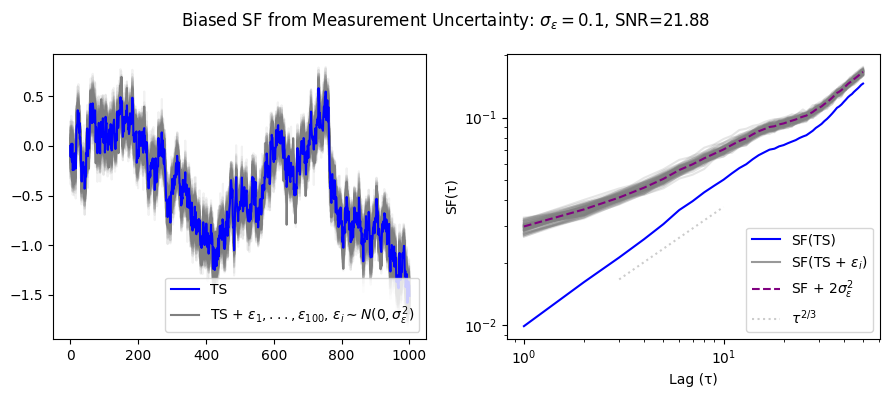

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(9, 4))
for i, x in enumerate(x_boot):
    ax[0].plot(x, c="grey", alpha=0.1)
ax[0].plot(
    x_boot[0],
    label=f"TS + $\mathbf{\epsilon}_1,...,\mathbf{\epsilon}_{{100}}$, $\mathbf{\epsilon}_i \sim N(0,\mathbf{\sigma}^2_{{\mathbf{\epsilon}}})$",
    color="grey",
)
ax[0].plot(ts_sim, label="TS", color="blue")
# Reorder the legend
handles, labels = ax[0].get_legend_handles_labels()
handles = [handles[1], handles[0]]
labels = [labels[1], labels[0]]
ax[0].legend(handles, labels, loc="lower right")
plt.suptitle(f"Biased SF from Measurement Uncertainty: $\mathbf{\sigma}_{{\mathbf{\epsilon}}}=${sigma_epsilon}, SNR={snr:.2f}")

ci_lower = np.percentile(sf_boot, 2.5, axis=0)
ci_upper = np.percentile(sf_boot, 97.5, axis=0)

# Plot
lags = np.arange(1, max_lag + 1)

# Plot with both bootstrap and pointwise SE intervals using fig, ax[1] syntax[1]
for sf in sf_boot:
    ax[1].plot(lags, sf, color="grey", alpha=0.2)
ax[1].plot(lags, sf_orig.sf_2, label="SF(TS)", color="blue")
ax[1].plot(lags, sf_boot[0], color="grey", alpha=0.8, label="SF(TS + $\mathbf{\epsilon}_i$)")
ax[1].plot(
    lags, sf_orig.sf_2 + 2*sigma_epsilon**2, label="SF + 2$\mathbf{\sigma}_{\mathbf{\epsilon}}^2$", color="purple", linestyle="--"
)
ax[1].plot(
    sf_orig.lag[2:10],
    0.008 * np.power(sf_orig.lag[2:10], 2 / 3),
    label="$\\tau^{2/3}$",
    color="black",
    linestyle=":",
    alpha=0.2,
)
ax[1].set_xlabel("Lag (τ)")
ax[1].set_ylabel("SF(τ)")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].legend(loc="lower right")
fig.tight_layout()
plt.show()

### Voyager data

## Sampling uncertainty

We want to model the uncertainty under repeated measurement scenarios, and therefore assess the robustness of estimated scaling behaviour: if we were to observe a slightly different interval, how much could the SF differ?.

Bootstrapping is a way to do this that involves re-sampling the original data, with replacement, in order to generate "plausible alternative realisations" of the data. Doing this in blocks preserves (at least the short-range component of) the correlation structure that we need for a time series.

However, we need to be transparent about what properties are being preserved, and what aren't (i.e., long-run correlations.)

### fBm

In [35]:
def block_bootstrap_sf(x, max_lag, block_size, n_bootstraps=1000, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    n = len(x)
    n_blocks = n // block_size
    sf_boot = np.zeros((n_bootstraps, max_lag))
    x_boot_all = []

    for b in range(n_bootstraps):
        indices = np.random.randint(0, n_blocks, n_blocks)
        x_boot = np.concatenate(
            [x[i * block_size : (i + 1) * block_size] for i in indices]
        )
        x_boot_all.append(x_boot)
        sf_boot[b] = sf_funcs.compute_sf(
            pd.DataFrame(x_boot), np.arange(1, max_lag + 1), [2], False, False, None
        ).sf_2

    return sf_boot, x_boot_all


# Parameters
max_lag = 50
block_size = 100
n_bootstraps = 50

# Compute original SF and bootstrapped confidence intervals
# For Voyager data
ts = ts_sim

sf_orig = sf_funcs.compute_sf(
    pd.DataFrame(ts), np.arange(1, max_lag+1), [2], False, False, None
)
sf_boot, x_boot = block_bootstrap_sf(ts, max_lag, block_size, n_bootstraps)

In [30]:
def visualize_block_index_mapping(original, boot_samples, block_size, n_samples=2):
    import matplotlib.pyplot as plt
    import numpy as np

    n = len(original)
    n_blocks = n // block_size

    fig, axes = plt.subplots(
        n_samples + 1, 1, figsize=(10, 1.5 * (n_samples + 1)), sharex=True
    )

    # --- Original Time Series ---
    ax0 = axes[0]
    ax0.plot(original, color="black")
    for i in range(n_blocks):
        start = i * block_size
        ax0.axvline(start, linestyle="--", alpha=0.5, color="black")

        ax0.text(
            start + block_size / 2,
            np.max(original) * 0.5,
            f"{i}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
        )
    ax0.set_title("Original Time Series with Block Indices", fontweight="bold")
    ax0.axvline(n, linestyle="--", alpha=0.5, color="black")

    # --- Bootstrapped Samples ---
    for sample_idx in range(n_samples):
        sample = boot_samples[sample_idx]
        ax = axes[sample_idx + 1]

        for i in range(0, len(sample), block_size):
            block = sample[i : i + block_size]

            # Identify origin block
            found_origin = -1
            for j in range(n_blocks):
                orig_block = original[j * block_size : (j + 1) * block_size]
                if np.allclose(block, orig_block, atol=1e-6):
                    found_origin = j
                    break

            ax.plot(range(i, i + len(block)), block, color="black", lw=0.5)
            ax.axvline(i, linestyle="--", alpha=0.7, color="black")
            ax.text(
                i + block_size / 2,
                np.max(sample) * 0.5,
                f"{found_origin}",
                ha="center",
                va="bottom",
                fontsize=9,
                bbox=dict(facecolor="white", edgecolor="black", boxstyle="round,pad=0.3"),
            )

        # Add final vertical line for the last block
        ax.axvline(len(sample), linestyle="--", alpha=0.7, color="black")
        ax.set_title(f"Bootstrapped Sample ({sample_idx + 1})")

    plt.tight_layout()
    plt.show()

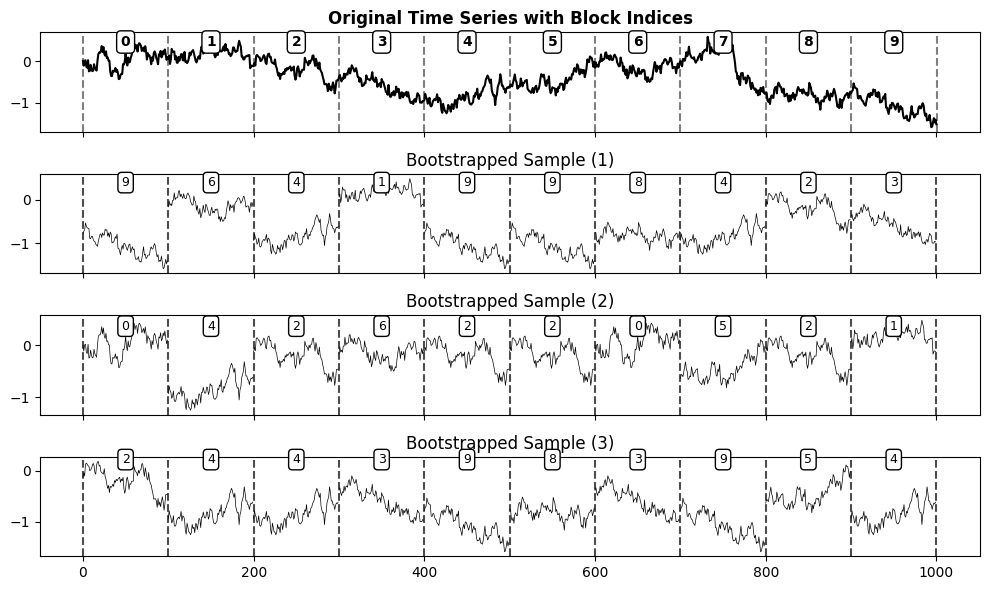

In [36]:

visualize_block_index_mapping(ts_sim, x_boot, block_size, n_samples=3)

Block bootstrapping perserves short-to-intermdiate scale autocorrelations, depending on the blocksize.
We need to make sure 
- the block size is large enough to retain sufficient autocorrelation, i.e., **block size > max lag > $\lambda_C$**
- given this block size, the signal is long enough for many blocks.

Also note, 
- this method will not preserve sharp gradients or bursts, i.e. *intermittency*, unless they're fully contained in blocks.

Overlapping blocks is less 'chunky' and preserves local dependencies somewhat better.

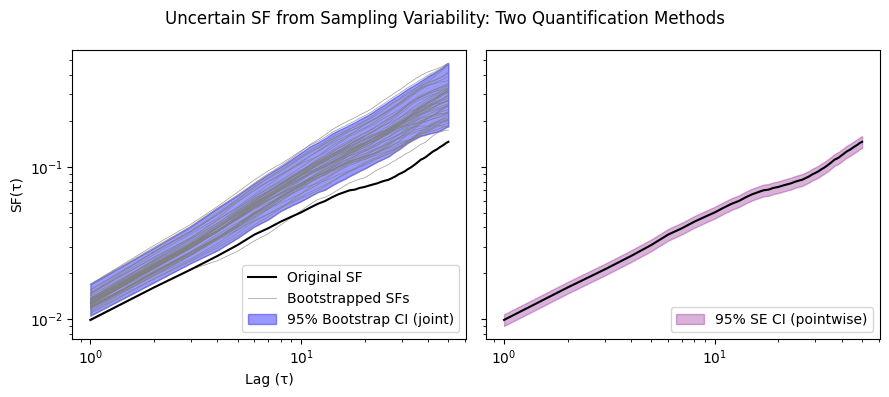

In [39]:
ci_lower = np.percentile(sf_boot, 2.5, axis=0)
ci_upper = np.percentile(sf_boot, 97.5, axis=0)

# Plot
lags = np.arange(1, max_lag + 1)

# Calculate standard error assuming chi-squared approximation (pointwise error bars)
n_pairs = np.array([len(ts) - tau for tau in range(1, max_lag + 1)])
sf_se = sf_orig.sf_2 * np.sqrt(2 / (n_pairs - 1))
ci_se_lower = sf_orig.sf_2 - 1.96 * sf_se
ci_se_upper = sf_orig.sf_2 + 1.96 * sf_se

# Plot with both bootstrap and pointwise SE intervals using fig, ax syntax
fig, ax = plt.subplots(1,2, figsize=(9, 4), sharey=True)
for sf in sf_boot:
    ax[0].plot(lags, sf, color="grey", alpha=0.8, lw=0.5)
ax[0].plot(lags[0], sf_boot[0][0], color="grey", alpha=0.8, lw = 0.5, label="Bootstrapped SFs")
ax[0].plot(lags, sf_orig.sf_2, label="Original SF", color="black")
ax[1].plot(lags, sf_orig.sf_2, color="black")
ax[0].fill_between(
    lags, ci_lower, ci_upper, color="blue", alpha=0.4, label="95% Bootstrap CI (joint)"
)
ax[1].fill_between(
    lags,
    ci_se_lower,
    ci_se_upper,
    color="purple",
    alpha=0.3,
    label="95% SE CI (pointwise)"
)
plt.suptitle("Uncertain SF from Sampling Variability: Two Quantification Methods")
ax[0].set_xlabel("Lag (τ)")
ax[0].set_ylabel("SF(τ)")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].legend(loc="lower right")

# Fix legend order
handles, labels = ax[0].get_legend_handles_labels()
handles = [handles[1], handles[0], handles[2]]
labels = [labels[1], labels[0], labels[2]]
ax[0].legend(handles, labels, loc="lower right")

fig.tight_layout()
plt.show()

We can see that the bootstrap interval is generally wider, especially at larger lags, reflecting the additional uncertainty due to autocorrelation and non-Gaussianity.

### Voyager

- As a demonstration dataset, we'll be working with the some magnetic field data from the Local Interstellar Medium, as measured by Voyager 2. The radial component of this data has particularly large measurement errors.
- NB: Low signal-to-noise ratio for Voyager is making corrected-SF negative. **Try just adding Gaussian noise with given sigma to time series, and run a bootstrap-like model with this. Compare this to corrected values.**

In [9]:
data_full = pd.read_pickle("../data/interim/voyager/voyager1_lism_cleaned.pkl")
data_res = data_full.resample("48s").mean()
data_res.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7461001 entries, 2012-08-25 00:00:00 to 2023-12-31 00:00:00
Freq: 48s
Data columns (total 4 columns):
 #   Column  Dtype  
---  ------  -----  
 0   F1      float32
 1   BR      float32
 2   BT      float32
 3   BN      float32
dtypes: float32(4)
memory usage: 170.8 MB


Text(0, 0.5, '$B_N$ (nT)')

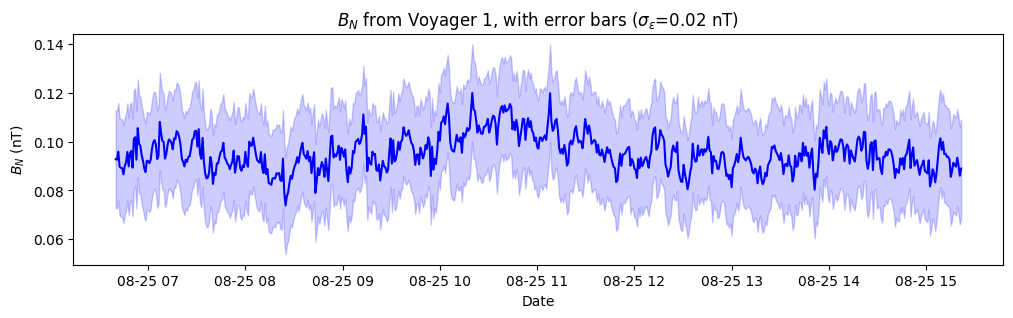

In [ ]:
# Plot error bars as shaded region
ts_v1 = data_res["2012-08-25 06:40:00":"2012-08-25 15:30"]["BN"]
sigma_eps = 0.02  # Standard deviation of noise
# Source: Rankin et al. (2023)

plt.figure(figsize=(12, 3))
plt.plot(ts_v1, label="BN", color="blue")
plt.fill_between(
    ts_v1.index,
    ts_v1 - sigma_eps,
    ts_v1 + sigma_eps,
    color="blue",
    alpha=0.2,
)
plt.title(f"$B_N$ from Voyager 1, with error bars ($\mathbf{\sigma}_{{\mathbf{\epsilon}}}$={sigma_eps} nT)")
plt.xlabel("Date")
plt.ylabel("$B_N$ (nT)")

## Add noise to Voyager data

There was an issue here where the uncertainties overpowered the fluctuations, resulting in theoretical "de-biased" SF that was negative...

Let's just simulate the noise as before to get more physical results.

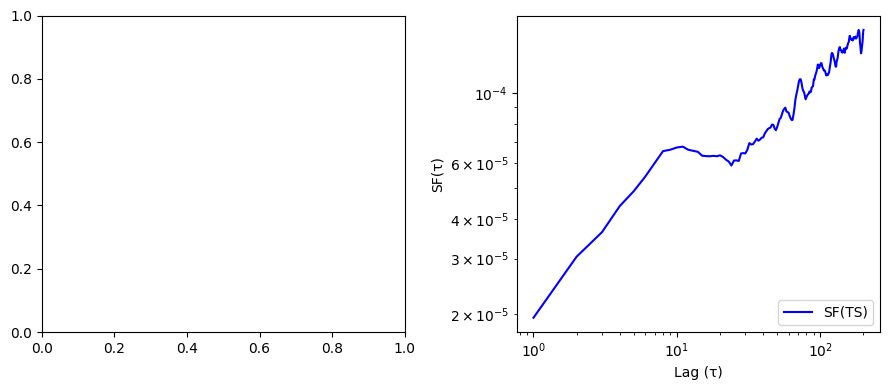

In [ ]:
max_lag = 200

sf_orig = sf_funcs.compute_sf(
    pd.DataFrame(ts_v1), np.arange(1, max_lag + 1), [2], False, False, None
)

fig, ax = plt.subplots(1, 2, figsize=(9, 4))

ax[1].plot(sf_orig.lag, sf_orig.sf_2, label="SF(TS)", color="blue")
#ax[1].plot(lags, sf_boot[0], color="grey", alpha=0.8, label="SF(TS + $\mathbf{\epsilon}_i$)")
# ax[1].plot(
#     sf_orig.lag,
#     sf_orig.sf_2 - 2 * sigma_eps,
#     label="SF - 2$\mathbf{\sigma}_{\mathbf{\epsilon}}$",
#     color="purple",
#     linestyle="--",
# )
ax[1].set_xlabel("Lag (τ)")
ax[1].set_ylabel("SF(τ)")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].legend(loc="lower right")
fig.tight_layout()
plt.show()

In [12]:
np.std(noise_sim)

NameError: name 'noise_sim' is not defined

In [ ]:
sigma_eps

0.02

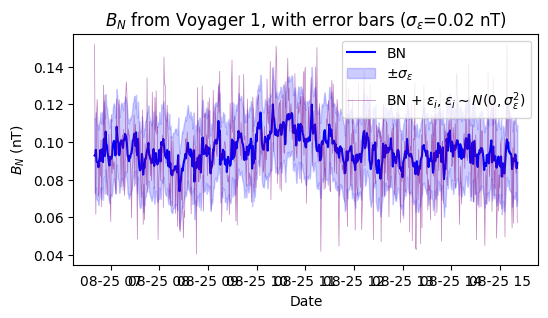

In [ ]:
noise_sim = np.random.normal(0, sigma_eps, len(ts_v1))

ts_v1_noisy = ts_v1 + noise_sim
plt.figure(figsize=(6, 3))
plt.plot(ts_v1, label="BN", color="blue")
plt.fill_between(
    ts_v1.index,
    ts_v1 - sigma_eps,
    ts_v1 + sigma_eps,
    color="blue",
    alpha=0.2,
    label="$\pm \mathbf{\sigma}_{\mathbf{\epsilon}}$",
)
plt.plot(ts_v1_noisy, label="BN + $\mathbf{\epsilon}_i, \mathbf{\epsilon}_i \sim N(0,\mathbf{\sigma}^2_{\mathbf{\epsilon}})$", color="purple", alpha=0.5, lw=0.5)

plt.title(
    f"$B_N$ from Voyager 1, with error bars ($\mathbf{\sigma}_{{\mathbf{\epsilon}}}$={sigma_eps} nT)"
)
plt.xlabel("Date")
plt.ylabel("$B_N$ (nT)")
plt.legend()

### Fit uncertainty

# Daily data
Look at power law!

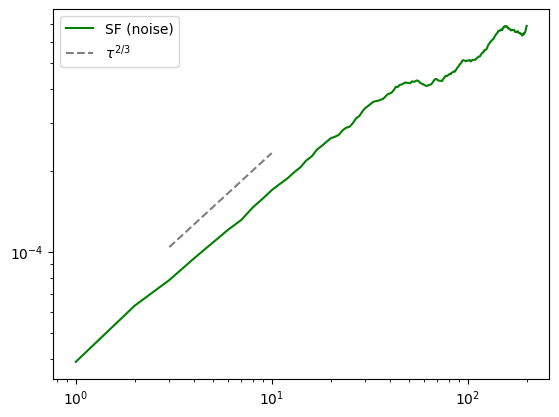

In [ ]:
max_lag = 200

sf_orig = sf_funcs.compute_sf(
    pd.DataFrame(ts_v1), np.arange(1, max_lag + 1), [2], False, False, None
)

plt.plot(
    sf_orig.lag,
    sf_orig.sf_2,
    label="SF (noise)",
    color="green",
)

# Plot 2/3 power law
plt.plot(
    sf_orig.lag[2:10],
    0.00005 * np.power(sf_orig.lag[2:10], 2 / 3),
    label="$\\tau^{2/3}$",
    color="black",
    linestyle="--",
    alpha=0.5,
)
plt.legend()
plt.xscale("log")
plt.yscale("log")

True time series is way more autocorrelated than noise! But... we have averaged the time series!